Test accuracy: 0.995


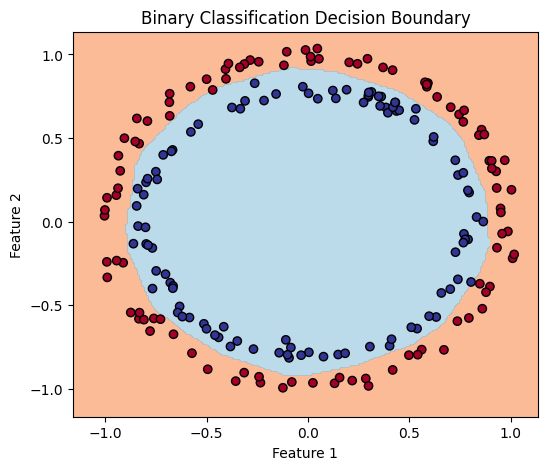

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Make results more consistent
np.random.seed(42)
tf.random.set_seed(42)

# Generate circular binary classification data
data, target = make_circles(
    n_samples=1000,
    noise=0.03,
    random_state=42
)

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)

# Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
model.fit(
    x_train,
    y_train,
    epochs=25,
    verbose=0
)

# Evaluate performance
loss_value, accuracy_value = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {accuracy_value:.3f}")

# Create grid for visualization
x_min, x_max = data[:, 0].min() - 0.1, data[:, 0].max() + 0.1
y_min, y_max = data[:, 1].min() - 0.1, data[:, 1].max() + 0.1

x_vals = np.linspace(x_min, x_max, 200)
y_vals = np.linspace(y_min, y_max, 200)

grid_x, grid_y = np.meshgrid(x_vals, y_vals)
grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

# Predict over grid
grid_pred = model.predict(grid_points, verbose=0)
grid_pred = grid_pred.reshape(grid_x.shape)

# Plot decision boundary
plt.figure(figsize=(6, 5))
plt.contourf(
    grid_x,
    grid_y,
    grid_pred > 0.5,
    cmap=plt.cm.RdYlBu,
    alpha=0.6
)

# Plot test points
plt.scatter(
    x_test[:, 0],
    x_test[:, 1],
    c=y_test,
    cmap=plt.cm.RdYlBu,
    edgecolors="black"
)

plt.title("Binary Classification Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()